# SageMaker Pipelines with MLflow Tracking

This notebook demonstrates an end-to-end MLOps workflow using **Amazon SageMaker Pipelines** with **MLflow experiment tracking**.

## Key Learning Objectives

**1. The `@step` decorator — Pipelines without rewriting your code**  
The `@step` decorator lets you turn existing Python functions into managed pipeline steps with minimal changes. This project includes two pipeline implementations (traditional inline wrapping vs. `@step` decorator) so you can compare and see how little your ML code needs to change. 

**2. S3-triggered Batch Transform — Event-driven inference**  
Upload a CSV to S3 and automatically get predictions back — no manual intervention. A Lambda function dynamically picks the latest approved model from the registry and launches a Batch Transform job.

---

**Steps covered:**
1. Set up the environment and detect your MLflow tracking server
2. Generate a `config.yaml` for remote function execution
3. Test the full ML pipeline locally (preprocess → train → evaluate → quality gate → register)
4. Submit the pipeline to SageMaker for managed, scalable execution
5. Approve and deploy the registered model to a real-time endpoint
6. Run batch inference via Batch Transform
7. Set up automated event-driven batch inference with Lambda + S3

**Dataset:** [UCI Abalone](https://archive.ics.uci.edu/ml/datasets/abalone) — predict age (rings) from physical measurements.  
**Model:** XGBoost gradient-boosted tree regressor with early stopping.  
**Quality Gate:** Model is only registered if MSE < 6.0 AND R² > 0.5.

This example shows how to structure a Python workspace in modular way for building a SageMaker Pipeline with 
data preprocessing, training, evaluation, registry steps.

**Prerequisites:**
- SageMaker Studio JupyterLab space with an execution role
- An active MLflow tracking server (auto-detected below)
- Python 3.10+ kernel

### Step 1. Install dependencies and verify SDK versions

Uncomment the pip install cell below if running for the first time. The SageMaker SDK v3 ships as modular packages (`sagemaker-core`, `sagemaker-train`, `sagemaker-mlops`, etc.).

In [ ]:
%pip install -q -r local-requirements.txt

In [ ]:
# Suppress verbose logging from boto3/botocore/sagemaker
import logging
import warnings

# Suppress all INFO and DEBUG messages from noisy libraries
logging.getLogger("botocore").setLevel(logging.ERROR)
logging.getLogger("boto3").setLevel(logging.ERROR)
logging.getLogger("urllib3").setLevel(logging.ERROR)
logging.getLogger("sagemaker").setLevel(logging.ERROR)
logging.getLogger("sagemaker.config").setLevel(logging.ERROR)
logging.getLogger("sagemaker.remote_function").setLevel(logging.ERROR)
logging.getLogger("sagemaker.core").setLevel(logging.ERROR)
logging.getLogger("sagemaker.core.telemetry").setLevel(logging.ERROR)

# Suppress warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*TrainingJobName.*")

print("✓ Verbose logging suppressed")

In [ ]:
import sagemaker
import sagemaker.core
import sagemaker.train
import sagemaker.serve
import sagemaker.mlops
from importlib.metadata import version

print(f"sagemaker: {version('sagemaker')}")
print(f"sagemaker.core: {version('sagemaker.core')}")
print(f"sagemaker.train: {version('sagemaker.train')}")
print(f"sagemaker.server: {version('sagemaker.serve')}")
print(f"sagemaker.mlops: {version('sagemaker.mlops')}")

In [ ]:
import boto3
import numpy as np
import pandas as pd
import os
import json
from importlib.metadata import version

from sagemaker.core.helper.session_helper import Session, get_execution_role
import sagemaker.core
import sagemaker

from IPython.display import Javascript, HTML

print(f'sagemaker version: {version('sagemaker')}')

In [ ]:
boto_session = boto3.Session()
sagemaker_session = Session()
role = get_execution_role()
region = sagemaker_session.boto_region_name
sm_client = boto_session.client("sagemaker")

In [ ]:
NOTEBOOK_METADATA_FILE = "/opt/ml/metadata/resource-metadata.json"
domain_id = None

if os.path.exists(NOTEBOOK_METADATA_FILE):
    with open(NOTEBOOK_METADATA_FILE, "rb") as f:
        metadata = json.loads(f.read())
        domain_id = metadata.get('DomainId')
        space_name = metadata.get('SpaceName')

if not space_name:
    raise Exception(f"Cannot find the current domain. Make sure you run this notebook in a JupyterLab in the SageMaker AI Studio")
else:
    print(f"SageMaker domain id: {domain_id}")

if not space_name:
    raise Exception(f"Cannot find the current space name. Make sure you run this notebook in a JupyterLab in the SageMaker Studio")
else:
    print(f"Space name: {space_name}")
    
r = sm_client.describe_space(DomainId=domain_id, SpaceName=space_name)
user_profile_name = r['OwnershipSettings']['OwnerUserProfileName']

print(f"User profile name: {user_profile_name}")

### Step 2. Configure the SageMaker SDK for remote function execution

The `config.yaml` file tells the SageMaker SDK how to run each pipeline step as a remote training job. We need to generate it with environment-specific values (MLflow ARN, region, user profile) detected at runtime.

### MLflow setup

MLflow is used to log parameters, metrics, and model artifacts for every pipeline step.  
MLflow's **nested runs** feature groups child runs (one per step) under a single parent run, making it easy to compare pipeline executions.

Below we auto-detect the active MLflow tracking server from your SageMaker domain and save its ARN for use throughout the notebook.

In [ ]:
# Use the default MLflow app available (excluding Nova-Forge)
bucket_name = Session().default_bucket()

# Get active MLflow apps, excluding Nova-Forge-MLflow-App
apps = sm_client.list_mlflow_apps().get('Summaries', [])
active_apps = [a for a in apps 
               if a.get('Status') in ['Created', 'Updated'] 
               and a.get('Name') != 'Nova-Forge-MLflow-App']

if not active_apps:
    raise RuntimeError("No suitable MLflow apps found. Please create an MLflow app in SageMaker Studio.")

# Use the first available app (excluding Nova-Forge)
mlflow_app = sm_client.describe_mlflow_app(Arn=active_apps[0]['Arn'])
mlflow_arn = mlflow_app['Arn']

print(f"Using MLflow App: {mlflow_app.get('Name', 'MLflow')} (v{mlflow_app.get('MlflowVersion', 'N/A')})")
print(f"ARN: {mlflow_arn}")

mlflow_experiment_name = "abalone-sm-pipeline-exp"

## Create the config file

The `config.yaml` ensures all remote functions (pipeline steps) share the same execution settings:

| Setting | Purpose |
|---------|--------|
| `InstanceType` | Compute instance for each step (`ml.m5.xlarge`) |
| `EnvironmentVariables` | Injects MLflow URI, experiment name, user, and region into remote jobs |
| `Dependencies` | Pip requirements installed inside the container |
| `IncludeLocalWorkDir` | Ships local Python modules (the `steps/` package) to the remote job |
| `CustomFileFilter` | Excludes data files, models, notebooks, and caches from the upload |

You can also specify `image_uri` to use a custom container image.

In [ ]:
config_yaml = f"""
SchemaVersion: '1.0'
SageMaker:
  PythonSDK:
    Modules:
      TelemetryOptOut: true
      RemoteFunction:
        InstanceType: ml.m5.xlarge
        EnvironmentVariables: {{'MLFLOW_TRACKING_URI': {mlflow_arn}, 'LOGNAME': {user_profile_name}, 'MLFLOW_EXPERIMENT_NAME': {mlflow_experiment_name}, 'AWS_REGION': {region}}}
        Dependencies: ./requirements.txt
        IncludeLocalWorkDir: True
        CustomFileFilter:
          IgnoreNamePatterns:
          - "data/*"
          - "models/*"
          - "*.ipynb"
          - "__pycache__"

"""

print(config_yaml, file=open('config.yaml', 'w'))
print(config_yaml)

## Step 3. Understand the pipeline steps

The pipeline is composed of **5 steps**, each implemented in a separate Python module under `steps/`:

| # | Step | File | What it does |
|---|------|------|--------------|
| 1 | Preprocess | `steps/preprocess.py` | Load Abalone CSV from S3, apply numeric scaling + one-hot encoding, split 70/15/15 |
| 2 | Train | `steps/train.py` | Train XGBoost regressor (50 rounds max, early stopping at 5) |
| 3 | Evaluate | `steps/evaluation.py` | Compute MSE, RMSE, MAE, MAPE, R² on the test set |
| 4 | Quality Check | `steps/check_quality.py` | Compare metrics to thresholds; emit pass/fail decision |
| 5 | Register | `steps/register.py` | Package model, upload to S3, register in SageMaker Model Registry |

Each step logs to MLflow as a nested child run under a shared parent run.

In [ ]:
# !pygmentize steps/preprocess.py

In [ ]:
# !pygmentize steps/train.py

In [ ]:
# !pygmentize steps/evaluation.py

In [ ]:
# !pygmentize steps/register.py

## Test pipeline steps locally

Before submitting to SageMaker's managed infrastructure, we validate the full pipeline locally.  
Each step function is called directly in-process — this is fast iteration without waiting for remote jobs.

**MLflow nested run pattern:** We create a parent run, capture its `run_id`, then immediately end it.  
Each step re-opens that parent run and creates a nested child run inside it.  
This works locally because we ended the parent run; in remote execution each step runs in a separate process so there's no conflict.

In [ ]:
import os
import mlflow

from steps.preprocess import preprocess
from steps.train import train
from steps.evaluation import evaluate
from steps.register import register
from steps.check_quality import check_quality

os.environ['MLFLOW_TRACKING_URI'] = mlflow_arn

bucket=sagemaker_session.default_bucket()
input_path = (f"s3://sagemaker-example-files-prod-{sagemaker_session.boto_region_name}/datasets"
              f"/tabular/uci_abalone/abalone.csv")

model_approval_status_param = "PendingManualApproval"

model_pkg_group_name = "abalone-model-group"

sm_pipeline_name = 'abalone-sm-pipeline'

mlflow.set_experiment(mlflow_experiment_name)

# NOTE: Create the parent run, capture run_id, then end it.
# The step functions internally call mlflow.start_run(run_id=run_id) to resume
# this run. That only works if the run is not already active in the current process.
# When running via @remote/@step, each step runs in a separate process so there is
# no conflict. For local testing, we must end the parent run first.
parent_run = mlflow.start_run(run_name=f"local-{sm_pipeline_name}")
run_id = parent_run.info.run_id
print(run_id)
mlflow.end_run()

In [ ]:
## preproces step
data = preprocess(input_path, experiment_name=mlflow_experiment_name, run_id=run_id)

## training step
model = train(train_df=data[0], validation_df=data[1], experiment_name=mlflow_experiment_name, run_id=run_id)

## evaluation step
evaluation_results = evaluate(model=model, test_df=data[2], experiment_name=mlflow_experiment_name, run_id=run_id)

## quality check step 
quality_check_result = check_quality(
    evaluation=evaluation_results,
    mse_threshold=6.0,
    r2_threshold=0.5,
    experiment_name=mlflow_experiment_name,
    run_id=run_id
)

print("="*60)
result_status = "✓ PASS" if quality_check_result["should_register"] else "✗ FAIL"
print(f"Quality Check Result: {result_status}")
print(f"Decision: {quality_check_result["decision_reason"]}")
print("="*60)

## model registration step
model_register=register(
    model=model,
    evaluation=evaluation_results,
    model_approval_status=model_approval_status_param,
    model_package_group_name=model_pkg_group_name,
    bucket=bucket,
    experiment_name=mlflow_experiment_name,
    run_id=run_id
)

### Step 4. Run the Amazon SageMaker Pipeline

After validating locally, we submit the pipeline to SageMaker for managed execution.  
Each step runs as a separate SageMaker Training Job on `ml.m5.xlarge` instances (defined in `config.yaml`).  
The SDK automatically handles:
- Serializing function code and arguments to S3
- Building the DAG from data dependencies between steps
- Orchestrating execution order and passing intermediate results

**Notice:** We use `pipeline_decorated.py` which leverages the `@step` decorator. Compare it with `pipeline.py` (traditional approach) to see the difference. The decorated version is cleaner because:
- No boilerplate `step(fn, name=...)` wrapping at call time
- Your existing ML functions stay almost unchanged — just add `@step`
- The pipeline script reads like normal Python with function calls

In [ ]:
# !python pipeline.py --mlflow_tracking_uri {mlflow_arn} --mlflow_experiment_name {mlflow_experiment_name} --sagemaker_pipeline_name {sm_pipeline_name}

In [ ]:
!python pipeline_decorated.py --mlflow_tracking_uri {mlflow_arn} --mlflow_experiment_name {mlflow_experiment_name} --sagemaker_pipeline_name {sm_pipeline_name}


### Step 5. Observe Amazon SageMaker Pipeline execution

After starting the pipeline, you can monitor its progress in the SageMaker Studio **Pipelines** tab.  
The link below opens the pipeline graph view where you can see each step's status (running, succeeded, failed) and inspect CloudWatch logs for individual steps.

In [ ]:
from IPython.display import HTML

# Show the pipeline link
display(
    HTML('<b>See <a target="top" href="https://studio-{}.studio.{}.sagemaker.aws/pipelines/{}/graph">the pipeline</a> in the Studio UI</b>'.format(
            domain_id, region, sm_pipeline_name))
)

In [ ]:
# wait until the pipeline finishes its execution ~ 17 minutes

import time
import boto3

sm_client = boto3.client("sagemaker", region_name=region)

pipeline_name = "abalone-sm-pipeline"  

# Get latest execution
executions = sm_client.list_pipeline_executions(
    PipelineName=pipeline_name, SortBy="CreationTime", SortOrder="Descending", MaxResults=1
)
execution_arn = executions["PipelineExecutionSummaries"][0]["PipelineExecutionArn"]

In [ ]:
# uncomment these code block if you wanna wait until the model from the pipeline gets registered
while True:
    resp = sm_client.describe_pipeline_execution(PipelineExecutionArn=execution_arn)
    status = resp['PipelineExecutionStatus']
    
    steps = sm_client.list_pipeline_execution_steps(PipelineExecutionArn=execution_arn)
    print(f"\n[{time.strftime('%H:%M:%S')}] Pipeline: {status}")
    for s in reversed(steps['PipelineExecutionSteps']):
        print(f"  {s['StepName']:35s} {s['StepStatus']}")
        if s['StepStatus'] == 'Failed' and s.get('FailureReason'):
            print(f"    ↳ {s['FailureReason'][:120]}")
    
    if status in ('Succeeded', 'Failed', 'Stopped'):
        print(f"\nPipeline finished: {status}")
        break
    
    time.sleep(120)

Here's what the end-end pipeline looks like once the execution is successful:

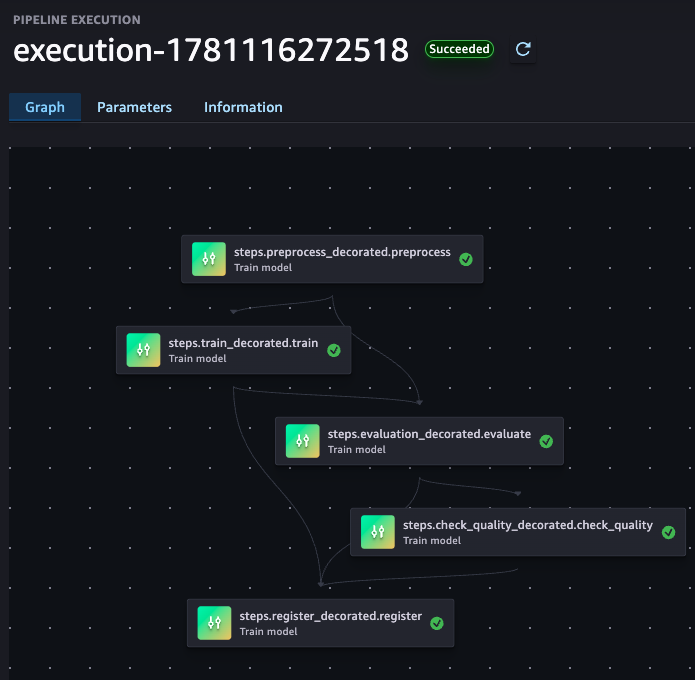

### Step 6. Approve and Deploy the latest model version

After the pipeline completes, the registered model package is in `PendingManualApproval` status. We need to approve it before deploying.

**Important:** We deploy using `sagemaker.core.resources` classes (`Model`, `EndpointConfig`, `Endpoint`) with `ContainerDefinition(model_package_name=...)`. This preserves the full model lineage (model package → model → endpoint) in SageMaker. Using the SDK's `ModelBuilder` with extracted S3/image URIs would break this lineage chain.

In [ ]:
# Get the latest model package version from the group
latest_packages = sm_client.list_model_packages(
    ModelPackageGroupName=model_pkg_group_name,
    SortBy='CreationTime',
    SortOrder='Descending',
    MaxResults=1
)
latest_package_arn = latest_packages['ModelPackageSummaryList'][0]['ModelPackageArn']
print(f"Latest model package: {latest_package_arn}")
print(f"Current status: {latest_packages['ModelPackageSummaryList'][0]['ModelApprovalStatus']}")

In [ ]:
import time
from sagemaker.core.resources import Model, EndpointConfig, Endpoint
from sagemaker.core.shapes.shapes import ContainerDefinition, ProductionVariant

# Approve the model package
sm_client.update_model_package(
    ModelPackageArn=latest_package_arn,
    ModelApprovalStatus='Approved'
)
print(f"Model package approved: {latest_package_arn}")

# Generate unique names for the deployment resources
timestamp = int(time.time())
model_name = f"abalone-model-{timestamp}"
config_name = f"abalone-config-{timestamp}"
endpoint_name = f"abalone-endpoint-{timestamp}"

# Deploy directly from model package ARN using sagemaker.core resources.
# This preserves the full lineage chain: model package -> model -> endpoint.
# Note: Using ModelBuilder with extracted s3_model_data_url and image_uri
# would create an orphaned model with NO reference back to the model package,
# breaking the lineage.
model = Model.create(
    model_name=model_name,
    containers=[ContainerDefinition(model_package_name=latest_package_arn)],
    execution_role_arn=role,
)
print(f"Model created: {model_name}")

config = EndpointConfig.create(
    endpoint_config_name=config_name,
    production_variants=[ProductionVariant(
        variant_name="AllTraffic",
        model_name=model_name,
        instance_type="ml.m5.xlarge",
        initial_instance_count=1,
    )]
)
print(f"Endpoint config created: {config_name}")

endpoint = Endpoint.create(
    endpoint_name=endpoint_name,
    endpoint_config_name=config_name,
)
print(f"Endpoint creating: {endpoint_name}")

# Wait for the endpoint to be in service
print("Waiting for endpoint to be InService...")
endpoint.wait_for_status(target_status="InService")
print(f"Endpoint is now InService: {endpoint_name}")

### Step 7. Test the endpoint

Send sample abalone data to the endpoint and get a prediction for the number of rings.

In [ ]:
from sagemaker.core.resources import Endpoint

# Use the endpoint_name from the deployment (check the output above)
endpoint_name = "abalone-endpoint-1780673243"  # Replace with your actual endpoint name
endpoint = Endpoint.get(endpoint_name=endpoint_name)


In [ ]:
# Sample abalone data (features after preprocessing):
# rings(label) is what we predict - the remaining columns are preprocessed features
sample_data = '0.455,0.365,0.095,0.514,0.2245,0.101,0.15,-0.63,0.77,1.0'

# Use the sagemaker.core Endpoint.invoke() method
response = endpoint.invoke(
    body=sample_data,
    content_type='text/csv',
    accept='text/csv'
)

prediction = response.body.read().decode('utf-8')
print(f'Endpoint: {endpoint_name}')
print(f'Input: {sample_data}')
print(f'Predicted rings: {prediction}')

In [ ]:
from IPython.display import Javascript, HTML

In [ ]:
# You can verify the model lineage is preserved by navigating to:
# SageMaker Console -> Endpoints -> select the endpoint -> check the Model reference
# The model should show the ModelPackageName linking back to the registered model package.

display(
    HTML('<b>Check <a target="top" href="https://console.aws.amazon.com/sagemaker/home?region={0}#/endpoints/{1}">the endpoint</a> in the console to verify lineage</b>'.format(
            region, endpoint_name))
)

### Step 8. Batch Transform for Batch Inference

Batch Transform is ideal for processing large datasets offline without the need for a persistent endpoint. It's cost-effective for scenarios where you don't need real-time predictions.

**Complete Workflow Architecture:**
```
┌─────────────────────────────────────────────────────────────────┐
│  Data Upload                                                    │
│  ────────────                                                   │
│  User/System uploads CSV → s3://bucket/batch-input/data.csv    │
└────────────────────────────┬────────────────────────────────────┘
                             │
                             ▼
┌─────────────────────────────────────────────────────────────────┐
│  S3 Event Notification                                          │
│  ──────────────────────                                         │
│  S3 detects ObjectCreated event                                 │
│  Filters: prefix=batch-input/, suffix=.csv                      │
└────────────────────────────┬────────────────────────────────────┘
                             │
                             ▼
┌─────────────────────────────────────────────────────────────────┐
│  Lambda Function Execution                                      │
│  ──────────────────────────                                     │
│  • Validates file and location                                  │
│  • Generates unique job name                                    │
│  • Calls sagemaker.create_transform_job()                       │
│  • Logs execution to CloudWatch                                 │
└────────────────────────────┬────────────────────────────────────┘
                             │
                             ▼
┌─────────────────────────────────────────────────────────────────┐
│  SageMaker Batch Transform Job                                  │
│  ──────────────────────────────                                 │
│  • Spins up ml.m5.xlarge instance(s)                            │
│  • Loads model from registry                                    │
│  • Processes data line-by-line                                  │
│  • Generates predictions                                        │
└────────────────────────────┬────────────────────────────────────┘
                             │
                             ▼
┌─────────────────────────────────────────────────────────────────┐
│  Results Storage                                                │
│  ────────────────                                               │
│  Predictions saved → s3://bucket/batch-output/filename/         │
│  Format: CSV with predictions                                   │
└─────────────────────────────────────────────────────────────────┘
```

**Key Benefits:**
- ✅ **Fully Automated** - No manual intervention
- ✅ **Scalable** - Handles multiple concurrent uploads
- ✅ **Cost-Efficient** - Lambda and Transform jobs are pay-per-use
- ✅ **Traceable** - Full lineage from model package to predictions
- ✅ **Monitored** - CloudWatch logs for debugging

**Best Practices:**
1. **File Naming** - Use timestamps or unique IDs in filenames
2. **Error Handling** - Lambda retries on failure (configurable)
3. **Monitoring** - Set up CloudWatch alarms for failed jobs
4. **Cleanup** - Consider lifecycle policies for old predictions
5. **Security** - Use VPC endpoints if working with sensitive data

---

In this example, we'll:
1. Prepare a batch of test data and upload it to S3
2. Create and run a Batch Transform job using the registered model
3. Monitor the job progress
4. Retrieve and analyze the predictions

In [ ]:
# Step 8.1: Prepare batch input data
# Create a CSV file with multiple samples for batch prediction
import pandas as pd
import numpy as np

# Generate some sample abalone data for batch processing
# These are preprocessed features similar to what the model expects
batch_samples = [
    [0.455, 0.365, 0.095, 0.514, 0.2245, 0.101, 0.15, -0.63, 0.77, 1.0],
    [0.530, 0.420, 0.135, 0.677, 0.2565, 0.142, 0.21, 0.52, -0.88, 1.0],
    [0.350, 0.265, 0.090, 0.226, 0.0995, 0.0485, 0.07, -1.25, 0.33, 1.0],
    [0.625, 0.485, 0.150, 1.234, 0.5285, 0.2165, 0.37, 1.48, -0.15, 1.0],
    [0.440, 0.365, 0.125, 0.516, 0.2155, 0.114, 0.155, -0.67, 0.69, 1.0],
    [0.550, 0.440, 0.150, 0.894, 0.3635, 0.1765, 0.295, 0.76, -0.51, 1.0],
    [0.395, 0.315, 0.105, 0.393, 0.1675, 0.081, 0.135, -0.94, 0.11, 1.0],
    [0.580, 0.470, 0.165, 0.995, 0.4265, 0.1875, 0.315, 0.98, -0.33, 1.0],
    [0.490, 0.380, 0.135, 0.621, 0.2565, 0.133, 0.195, -0.35, 0.28, 1.0],
    [0.600, 0.475, 0.205, 1.176, 0.5095, 0.216, 0.385, 1.31, -0.21, 1.0]
]

# Create a DataFrame without headers (SageMaker Batch Transform expects CSV without headers)
batch_df = pd.DataFrame(batch_samples)

# Save to local CSV file (no header, no index)
batch_input_file = 'batch_input.csv'
batch_df.to_csv(batch_input_file, header=False, index=False)

print(f"Created batch input file: {batch_input_file}")
print(f"Number of samples: {len(batch_samples)}")
print(f"\nFirst 3 rows:")
print(batch_df.head(3))

In [ ]:
# Step 8.2: Upload batch input to S3
import time

# Create S3 paths for batch transform
bucket = sagemaker_session.default_bucket()
batch_prefix = f'abalone-batch-transform/{int(time.time())}'
batch_input_s3 = f's3://{bucket}/{batch_prefix}/input/{batch_input_file}'
batch_output_s3 = f's3://{bucket}/{batch_prefix}/output'

# Upload the input file to S3
s3_client = boto3.client('s3')
s3_client.upload_file(
    batch_input_file, 
    bucket, 
    f'{batch_prefix}/input/{batch_input_file}'
)

print(f"Uploaded batch input to: {batch_input_s3}")
print(f"Batch output will be saved to: {batch_output_s3}")

In [ ]:
# Step 8.3: Create and start Batch Transform job using sagemaker.core
from sagemaker.core.resources import TransformJob, Model
from sagemaker.core.shapes import (
    TransformInput, 
    TransformOutput, 
    TransformResources, 
    TransformDataSource,  # Correct class name
    TransformS3DataSource,  # Correct class name
    ContainerDefinition
)

# Check if required variables exist, otherwise set defaults
if 'model_pkg_group_name' not in locals():
    model_pkg_group_name = "abalone-model-group"  # Match pipeline.py
    print(f"Using default model package group: {model_pkg_group_name}")

# Check if model_name exists from Step 6, otherwise create a model from the latest model package
if 'model_name' not in locals():
    # If model_name doesn't exist, create a model from the latest approved model package
    print("model_name not found. Creating a model from the latest model package...")
    
    # Get the latest approved model package
    latest_packages = sm_client.list_model_packages(
        ModelPackageGroupName=model_pkg_group_name,
        ModelApprovalStatus='Approved',
        SortBy='CreationTime',
        SortOrder='Descending',
        MaxResults=1
    )
    
    if not latest_packages['ModelPackageSummaryList']:
        raise ValueError(f"No approved model packages found in group: {model_pkg_group_name}")
    
    latest_package_arn = latest_packages['ModelPackageSummaryList'][0]['ModelPackageArn']
    print(f"Using model package: {latest_package_arn}")
    
    # Create a model from the model package for batch transform
    import time
    model_name = f"abalone-batch-model-{int(time.time())}"
    model = Model.create(
        model_name=model_name,
        containers=[ContainerDefinition(model_package_name=latest_package_arn)],
        execution_role_arn=role,
    )
    print(f"Created model: {model_name}")
else:
    print(f"Using existing model: {model_name}")

# Generate unique transform job name
import time
transform_job_name = f"abalone-batch-transform-{int(time.time())}"

# Create the batch transform job
# Note: We use the model created from the model package to preserve lineage
transform_job = TransformJob.create(
    transform_job_name=transform_job_name,
    model_name=model_name,  # Use the model created from the registered model package
    transform_input=TransformInput(
        data_source=TransformDataSource(
            s3_data_source=TransformS3DataSource(
                s3_data_type='S3Prefix',
                s3_uri=batch_input_s3
            )
        ),
        content_type='text/csv',
        split_type='Line'  # Process each line as a separate prediction
    ),
    transform_output=TransformOutput(
        s3_output_path=batch_output_s3,
        accept='text/csv',
        assemble_with='Line'  # Assemble output line by line
    ),
    transform_resources=TransformResources(
        instance_type='ml.m5.xlarge',
        instance_count=1
    )
)

print(f"\nBatch Transform job created: {transform_job_name}")
print(f"Status: {transform_job.transform_job_status}")
print(f"\nMonitoring job progress...")

In [ ]:
# Step 8.4: Monitor the Batch Transform job
import time

print(f"Waiting for batch transform job to complete...")
print(f"Job name: {transform_job_name}\n")

# Wait for the transform job to complete
# The wait() method for TransformJob doesn't take parameters, it waits until completion
try:
    transform_job.wait_for_status(target_status='Completed')
    print(f"✓ Batch Transform job completed successfully!")
except Exception as e:
    # If wait_for_status doesn't exist, use polling
    print("Polling job status...")
    while True:
        transform_job.refresh()
        status = transform_job.transform_job_status
        print(f"Current status: {status}")
        
        if status in ['Completed', 'Failed', 'Stopped']:
            break
        time.sleep(30)

# Refresh to get final status
transform_job.refresh()
final_status = transform_job.transform_job_status

if final_status == 'Completed':
    print(f"✓ Batch Transform job completed successfully!")
    print(f"Output location: {batch_output_s3}")
elif final_status == 'Failed':
    print(f"✗ Batch Transform job failed!")
    if hasattr(transform_job, 'failure_reason'):
        print(f"Failure reason: {transform_job.failure_reason}")
else:
    print(f"Batch Transform job ended with status: {final_status}")

In [ ]:
# Step 8.5: Retrieve and display batch predictions
if final_status == 'Completed':
    # List output files in S3
    output_prefix = f'{batch_prefix}/output'
    response = s3_client.list_objects_v2(Bucket=bucket, Prefix=output_prefix)
    
    if 'Contents' in response:
        # Get the output file (usually has .out extension)
        output_files = [obj['Key'] for obj in response['Contents'] if obj['Key'].endswith('.out')]
        
        if output_files:
            output_file_key = output_files[0]
            
            # Download the output file
            local_output_file = 'batch_output.csv.out'
            s3_client.download_file(bucket, output_file_key, local_output_file)
            
            # Read predictions
            predictions_df = pd.read_csv(local_output_file, header=None)
            predictions_df.columns = ['predicted_rings']
            
            # Display results
            print(f"\n{'='*60}")
            print("BATCH TRANSFORM RESULTS")
            print(f"{'='*60}\n")
            print(f"Total predictions: {len(predictions_df)}")
            print(f"\nPredicted number of rings for each abalone sample:\n")
            
            results_df = pd.DataFrame({
                'Sample #': range(1, len(predictions_df) + 1),
                'Predicted Rings': predictions_df['predicted_rings'].round(2)
            })
            print(results_df.to_string(index=False))
            
            print(f"\n{'='*60}")
            print(f"Summary Statistics:")
            print(f"{'='*60}")
            print(f"Mean predicted rings: {predictions_df['predicted_rings'].mean():.2f}")
            print(f"Min predicted rings:  {predictions_df['predicted_rings'].min():.2f}")
            print(f"Max predicted rings:  {predictions_df['predicted_rings'].max():.2f}")
            print(f"Std deviation:        {predictions_df['predicted_rings'].std():.2f}")
            
        else:
            print("No output files found with .out extension")
    else:
        print(f"No output found at: {batch_output_s3}")
else:
    print(f"\nSkipping results retrieval - job status: {final_status}")

### Step 9. Automated Batch Transform with S3 Event Triggers

**IMPORTANT:** The Lambda function is configured to **automatically use the latest approved model** from the model package group. Every time a file is uploaded to S3, Lambda queries SageMaker to find the most recent approved model version. This means:
- ✅ No manual updates needed after pipeline runs
- ✅ New model versions are automatically used once approved
- ✅ Model lineage is preserved (model package → model → batch transform)

Now let's implement an **event-driven workflow** where uploading a CSV file to S3 automatically triggers batch transform inference.

**Architecture:**
```
S3 Upload → S3 Event Notification → Lambda Function → SageMaker Batch Transform Job → Results in S3
```

**Components:**
1. **S3 Event Notification** - Detects new file uploads
2. **Lambda Function** - Starts the batch transform job
3. **IAM Roles** - Permissions for Lambda to invoke SageMaker
4. **Automatic Processing** - No manual intervention needed

This pattern is ideal for:
- Automated batch scoring pipelines
- Scheduled inference jobs
- Real-time data processing workflows

In [ ]:
# Step 9.1: Create Lambda function code for auto-triggering batch transform
# UPDATED: Lambda now dynamically looks up the LATEST approved model at runtime
lambda_function_code = '''import json
import boto3
import os
from datetime import datetime

sagemaker = boto3.client('sagemaker')

def lambda_handler(event, context):
    """
    Lambda function triggered by S3 upload to start SageMaker Batch Transform job.
    Automatically uses the latest approved model from the model package group.
    """
    try:
        # Get S3 event details
        s3_event = event['Records'][0]['s3']
        bucket_name = s3_event['bucket']['name']
        input_key = s3_event['object']['key']
        
        # Only process CSV files in the 'batch-input/' prefix
        if not input_key.startswith('batch-input/') or not input_key.endswith('.csv'):
            print(f"Skipping non-batch file: {input_key}")
            return {
                'statusCode': 200,
                'body': json.dumps('File skipped - not a batch input CSV')
            }
        
        # Get configuration from environment variables
        model_pkg_group_name = os.environ['MODEL_PACKAGE_GROUP_NAME']
        output_bucket = os.environ.get('OUTPUT_BUCKET', bucket_name)
        sagemaker_role = os.environ['SAGEMAKER_ROLE']
        
        print(f"Looking up latest approved model from: {model_pkg_group_name}")
        
        # DYNAMIC LOOKUP: Get the latest approved model package
        latest_packages = sagemaker.list_model_packages(
            ModelPackageGroupName=model_pkg_group_name,
            ModelApprovalStatus='Approved',
            SortBy='CreationTime',
            SortOrder='Descending',
            MaxResults=1
        )
        
        if not latest_packages.get('ModelPackageSummaryList'):
            error_msg = f"No approved models found in {model_pkg_group_name}"
            print(f"ERROR: {error_msg}")
            return {
                'statusCode': 400,
                'body': json.dumps({'error': error_msg})
            }
        
        latest_package = latest_packages['ModelPackageSummaryList'][0]
        latest_package_arn = latest_package['ModelPackageArn']
        model_version = latest_package.get('ModelPackageVersion', 'unknown')
        
        print(f"Found latest approved model:")
        print(f"  ARN: {latest_package_arn}")
        print(f"  Version: {model_version}")
        print(f"  Status: {latest_package['ModelApprovalStatus']}")
        
        # Create or reuse model from this package
        # Use a deterministic name based on package ARN to avoid creating duplicates
        package_id = latest_package_arn.split('/')[-1]
        model_name = f"abalone-batch-model-v{model_version}"
        
        try:
            # Check if model already exists
            sagemaker.describe_model(ModelName=model_name)
            print(f"Using existing model: {model_name}")
        except sagemaker.exceptions.ClientError as e:
            if e.response['Error']['Code'] == 'ValidationException':
                # Model doesn't exist, create it
                print(f"Creating new model: {model_name}")
                sagemaker.create_model(
                    ModelName=model_name,
                    Containers=[{
                        'ModelPackageName': latest_package_arn
                    }],
                    ExecutionRoleArn=sagemaker_role
                )
                print(f"Model created: {model_name}")
            else:
                raise
        
        # Generate unique job name with timestamp
        timestamp = datetime.now().strftime('%Y%m%d-%H%M%S')
        file_name = input_key.split('/')[-1].replace('.csv', '').replace('_', '-')
        transform_job_name = f"auto-batch-{file_name}-{timestamp}"
        
        # Define input and output S3 paths
        input_s3_uri = f"s3://{bucket_name}/{input_key}"
        output_s3_prefix = f"s3://{output_bucket}/batch-output/{file_name}/{timestamp}/"
        
        print(f"Starting batch transform job: {transform_job_name}")
        print(f"Input: {input_s3_uri}")
        print(f"Output: {output_s3_prefix}")
        
        # Create batch transform job
        response = sagemaker.create_transform_job(
            TransformJobName=transform_job_name,
            ModelName=model_name,
            TransformInput={
                'DataSource': {
                    'S3DataSource': {
                        'S3DataType': 'S3Prefix',
                        'S3Uri': input_s3_uri
                    }
                },
                'ContentType': 'text/csv',
                'SplitType': 'Line'
            },
            TransformOutput={
                'S3OutputPath': output_s3_prefix,
                'Accept': 'text/csv',
                'AssembleWith': 'Line'
            },
            TransformResources={
                'InstanceType': 'ml.m5.xlarge',
                'InstanceCount': 1
            }
        )
        
        print(f"Successfully started transform job: {transform_job_name}")
        
        return {
            'statusCode': 200,
            'body': json.dumps({
                'message': 'Batch transform job started successfully',
                'transformJobName': transform_job_name,
                'modelName': model_name,
                'modelVersion': model_version,
                'modelPackageArn': latest_package_arn,
                'inputFile': input_s3_uri,
                'outputLocation': output_s3_prefix
            })
        }
        
    except Exception as e:
        print(f"Error starting batch transform job: {str(e)}")
        import traceback
        traceback.print_exc()
        return {
            'statusCode': 500,
            'body': json.dumps({
                'error': str(e)
            })
        }
'''

# Save Lambda function code to file
lambda_code_file = 'lambda_batch_transform_trigger.py'
with open(lambda_code_file, 'w') as f:
    f.write(lambda_function_code)

print(f"Lambda function code saved to: {lambda_code_file}")
print(f"\nFunction features:")
print("  ✓ Triggered by S3 PUT events")
print("  ✓ Validates CSV files in 'batch-input/' prefix")
print("  ✓ DYNAMICALLY finds latest approved model at runtime")
print("  ✓ Creates SageMaker model if it doesn't exist")
print("  ✓ Generates unique job names with timestamps")
print("  ✓ Comprehensive error handling and logging")
print("\n⚡ ALWAYS USES THE LATEST APPROVED MODEL! ⚡")

In [ ]:
# Step 9.2: Create IAM role and policy for Lambda function
import json

# Lambda execution role policy
lambda_policy = {
    "Version": "2012-10-17",
    "Statement": [
        {
            "Effect": "Allow",
            "Action": [
                "logs:CreateLogGroup",
                "logs:CreateLogStream",
                "logs:PutLogEvents"
            ],
            "Resource": "arn:aws:logs:*:*:*"
        },
        {
            "Effect": "Allow",
            "Action": [
                "sagemaker:*"
            ],
            "Resource": "*"
        },
        {
            "Effect": "Allow",
            "Action": [
                "s3:*"
            ],
            "Resource": "*"
        },
        {
            "Effect": "Allow",
            "Action": [
                "iam:PassRole"
            ],
            "Resource": "*",
            "Condition": {
                "StringEquals": {
                    "iam:PassedToService": "sagemaker.amazonaws.com"
                }
            }
        }
    ]
}

# Lambda trust policy (assume role policy)
lambda_trust_policy = {
    "Version": "2012-10-17",
    "Statement": [
        {
            "Effect": "Allow",
            "Principal": {
                "Service": "lambda.amazonaws.com"
            },
            "Action": "sts:AssumeRole"
        }
    ]
}

# Save policies to files
with open('lambda_execution_policy.json', 'w') as f:
    json.dump(lambda_policy, f, indent=2)

with open('lambda_trust_policy.json', 'w') as f:
    json.dump(lambda_trust_policy, f, indent=2)

print("IAM policies created:")
print(f"  ✓ lambda_execution_policy.json - Permissions for Lambda")
print(f"  ✓ lambda_trust_policy.json - Trust relationship")
print(f"\nPermissions granted:")
print(f"  • CloudWatch Logs (for Lambda logging)")
print(f"  • SageMaker (all actions - sagemaker:*)")
print(f"  • S3 (all actions - s3:*)")
print(f"  • IAM (pass SageMaker execution role)")

In [ ]:
# Step 9.3: Create Lambda function using boto3
import zipfile
import time

# Create IAM role for Lambda
iam_client = boto3.client('iam')
lambda_client = boto3.client('lambda')

lambda_role_name = 'BatchTransformTriggerLambdaRole'

try:
    # Create IAM role for Lambda
    print(f"Creating IAM role: {lambda_role_name}...")
    
    lambda_role_response = iam_client.create_role(
        RoleName=lambda_role_name,
        AssumeRolePolicyDocument=json.dumps(lambda_trust_policy),
        Description='Role for Lambda to trigger SageMaker Batch Transform jobs'
    )
    lambda_role_arn = lambda_role_response['Role']['Arn']
    print(f"✓ Created role: {lambda_role_arn}")
    
    # Attach inline policy to role
    print("Attaching execution policy to role...")
    iam_client.put_role_policy(
        RoleName=lambda_role_name,
        PolicyName='BatchTransformTriggerPolicy',
        PolicyDocument=json.dumps(lambda_policy)
    )
    print("✓ Policy attached")
    
    # Wait for role to propagate
    print("Waiting for IAM role to propagate...")
    time.sleep(10)
    
except iam_client.exceptions.EntityAlreadyExistsException:
    print(f"Role {lambda_role_name} already exists, using existing role...")
    lambda_role_arn = iam_client.get_role(RoleName=lambda_role_name)['Role']['Arn']
    # Update the policy in case it changed
    iam_client.put_role_policy(
        RoleName=lambda_role_name,
        PolicyName='BatchTransformTriggerPolicy',
        PolicyDocument=json.dumps(lambda_policy)
    )
    print("✓ Updated existing role policy")

# Create deployment package (zip file with Lambda code)
lambda_zip_file = 'lambda_function.zip'
with zipfile.ZipFile(lambda_zip_file, 'w') as zipf:
    zipf.write(lambda_code_file, 'lambda_function.py')

print(f"\n✓ Created Lambda deployment package: {lambda_zip_file}")

# Read the zip file
with open(lambda_zip_file, 'rb') as f:
    lambda_zip_content = f.read()

# Lambda function configuration
lambda_function_name = 'BatchTransformAutoTrigger'

try:
    # Create Lambda function
    print(f"\nCreating Lambda function: {lambda_function_name}...")
    
    lambda_response = lambda_client.create_function(
        FunctionName=lambda_function_name,
        Runtime='python3.12',
        Role=lambda_role_arn,
        Handler='lambda_function.lambda_handler',
        Code={'ZipFile': lambda_zip_content},
        Description='Auto-trigger SageMaker Batch Transform on S3 upload',
        Timeout=60,
        MemorySize=256,
        Environment={
            'Variables': {
                'MODEL_PACKAGE_GROUP_NAME': model_pkg_group_name,
                'OUTPUT_BUCKET': bucket,
                'SAGEMAKER_ROLE': role
            }
        }
    )
    
    lambda_function_arn = lambda_response['FunctionArn']
    print(f"✓ Lambda function created: {lambda_function_arn}")
    
except lambda_client.exceptions.ResourceConflictException:
    print(f"Lambda function {lambda_function_name} already exists, updating...")
    
    # Wait for any in-progress updates to complete
    print("Checking Lambda status...")
    max_wait = 30  # seconds
    wait_interval = 2
    elapsed = 0
    
    while elapsed < max_wait:
        try:
            func_config = lambda_client.get_function_configuration(FunctionName=lambda_function_name)
            state = func_config.get('State', 'Active')
            last_update_status = func_config.get('LastUpdateStatus', 'Successful')
            
            if state == 'Active' and last_update_status in ['Successful', 'Failed']:
                print(f"✓ Lambda is ready (State: {state}, LastUpdateStatus: {last_update_status})")
                break
            else:
                print(f"  Waiting for Lambda... (State: {state}, Status: {last_update_status})")
                time.sleep(wait_interval)
                elapsed += wait_interval
        except Exception as e:
            print(f"  Checking status: {e}")
            time.sleep(wait_interval)
            elapsed += wait_interval
    
    if elapsed >= max_wait:
        print(f"⚠️  Timed out waiting. Attempting update anyway...")
    
    # Update function code
    try:
        print("Updating function code...")
        lambda_client.update_function_code(
            FunctionName=lambda_function_name,
            ZipFile=lambda_zip_content
        )
        print("✓ Code updated")
        
        # Wait for code update
        time.sleep(3)
    except Exception as code_err:
        print(f"⚠️  Code update: {code_err}")
    
    # Update function configuration
    try:
        print("Updating function configuration...")
        lambda_client.update_function_configuration(
            FunctionName=lambda_function_name,
            Runtime='python3.12',
            Role=lambda_role_arn,
            Handler='lambda_function.lambda_handler',
            Timeout=60,
            MemorySize=256,
            Environment={
                'Variables': {
                    'MODEL_PACKAGE_GROUP_NAME': model_pkg_group_name,
                    'OUTPUT_BUCKET': bucket,
                    'SAGEMAKER_ROLE': role
                }
            }
        )
        print("✓ Configuration updated")
    except Exception as config_err:
        print(f"⚠️  Configuration update: {config_err}")
    
    lambda_function_arn = lambda_client.get_function(FunctionName=lambda_function_name)['Configuration']['FunctionArn']
    print(f"✓ Lambda function updated: {lambda_function_arn}")

print(f"\n{'='*60}")
print("Lambda Function Configuration:")
print(f"{'='*60}")
print(f"Function Name: {lambda_function_name}")
print(f"Function ARN: {lambda_function_arn}")
print(f"Runtime: Python 3.12")
print(f"Memory: 256 MB")
print(f"Timeout: 60 seconds")
print(f"\nEnvironment Variables:")
print(f"  MODEL_NAME: {model_name}")
print(f"  OUTPUT_BUCKET: {bucket}")
print(f"{'='*60}")

In [ ]:
# Step 9.4: Configure S3 event notification to trigger Lambda
s3_client = boto3.client('s3')

# Add Lambda invoke permission for S3
print("Adding S3 trigger permissions to Lambda...")
try:
    lambda_client.add_permission(
        FunctionName=lambda_function_name,
        StatementId='S3InvokeFunction',
        Action='lambda:InvokeFunction',
        Principal='s3.amazonaws.com',
        SourceArn=f'arn:aws:s3:::{bucket}'
    )
    print("✓ Permission added")
except lambda_client.exceptions.ResourceConflictException:
    print("✓ Permission already exists")

# Configure S3 bucket notification
print(f"\nConfiguring S3 event notification on bucket: {bucket}...")

# Get existing notification configuration
try:
    existing_config = s3_client.get_bucket_notification_configuration(Bucket=bucket)
    existing_lambda_configs = existing_config.get('LambdaFunctionConfigurations', [])
    
    # Remove old configuration for this Lambda if it exists
    existing_lambda_configs = [
        config for config in existing_lambda_configs 
        if config.get('LambdaFunctionArn') != lambda_function_arn
    ]
except:
    existing_lambda_configs = []

# Add new Lambda configuration
new_lambda_config = {
    'LambdaFunctionArn': lambda_function_arn,
    'Events': ['s3:ObjectCreated:*'],
    'Filter': {
        'Key': {
            'FilterRules': [
                {'Name': 'prefix', 'Value': 'batch-input/'},
                {'Name': 'suffix', 'Value': '.csv'}
            ]
        }
    }
}

existing_lambda_configs.append(new_lambda_config)

# Apply the notification configuration
s3_client.put_bucket_notification_configuration(
    Bucket=bucket,
    NotificationConfiguration={
        'LambdaFunctionConfigurations': existing_lambda_configs
    }
)

print("✓ S3 event notification configured")
print(f"\n{'='*60}")
print("S3 Event Trigger Configuration:")
print(f"{'='*60}")
print(f"Bucket: {bucket}")
print(f"Trigger: s3:ObjectCreated:*")
print(f"Filter Prefix: batch-input/")
print(f"Filter Suffix: .csv")
print(f"Lambda Function: {lambda_function_name}")
print(f"{'='*60}")
print(f"\n✅ Setup Complete!")
print(f"\nNow, any CSV file uploaded to:")
print(f"  s3://{bucket}/batch-input/")
print(f"will automatically trigger a batch transform job!")

In [ ]:
# Step 9.5: Test the automated workflow by uploading a file
import time

# Create test batch data
test_batch_data = [
    [0.455, 0.365, 0.095, 0.514, 0.2245, 0.101, 0.15, -0.63, 0.77, 1.0],
    [0.530, 0.420, 0.135, 0.677, 0.2565, 0.142, 0.21, 0.52, -0.88, 1.0],
    [0.350, 0.265, 0.090, 0.226, 0.0995, 0.0485, 0.07, -1.25, 0.33, 1.0],
]

test_df = pd.DataFrame(test_batch_data)
test_file = 'test_auto_batch.csv'
test_df.to_csv(test_file, header=False, index=False)

print(f"Created test file: {test_file}")
print(f"Number of samples: {len(test_batch_data)}\n")

# Upload to the batch-input/ prefix to trigger Lambda
test_s3_key = f'batch-input/{test_file}'
print(f"Uploading to s3://{bucket}/{test_s3_key} ...")

s3_client.upload_file(test_file, bucket, test_s3_key)
print(f"✓ File uploaded!")

print(f"\n{'='*60}")
print("⚡ AUTOMATED WORKFLOW TRIGGERED!")
print(f"{'='*60}")
print(f"1. S3 detected the new file upload")
print(f"2. Lambda function '{lambda_function_name}' is being invoked")
print(f"3. Batch Transform job will start automatically")
print(f"4. Results will be saved to: s3://{bucket}/batch-output/")
print(f"\nWaiting 10 seconds for Lambda to process...")
time.sleep(10)

# Check CloudWatch Logs for Lambda execution
print(f"\n{'='*60}")
print("Checking recent transform jobs...")
print(f"{'='*60}")

# List recent transform jobs
recent_jobs = sm_client.list_transform_jobs(
    SortBy='CreationTime',
    SortOrder='Descending',
    MaxResults=5
)

print(f"\nRecent Batch Transform Jobs:")
for job in recent_jobs['TransformJobSummaries']:
    job_name = job['TransformJobName']
    status = job['TransformJobStatus']
    created = job['CreationTime'].strftime('%Y-%m-%d %H:%M:%S')
    
    # Highlight auto-triggered jobs
    if 'auto-batch' in job_name:
        print(f"  🎯 {job_name}")
        print(f"     Status: {status}")
        print(f"     Created: {created}")
    else:
        print(f"  • {job_name} - {status}")

print(f"\n{'='*60}")
print("✅ Automated workflow is now active!")
print(f"{'='*60}")
print(f"\nTo monitor Lambda executions:")
print(f"  aws logs tail /aws/lambda/{lambda_function_name} --follow")
print(f"\nTo upload more files:")
print(f"  aws s3 cp your_data.csv s3://{bucket}/batch-input/")

### Step 9.5b: Download and View Batch Transform Results

After the batch transform job completes, let's download and display the prediction results.

In [ ]:
# Step 9.5b: Download and display batch transform results
import boto3
import pandas as pd
from io import StringIO
import time

s3_client = boto3.client('s3')
sm_client = boto3.client('sagemaker')

print("="*60)
print("BATCH TRANSFORM RESULTS")
print("="*60)

# Find the most recent auto-batch job
recent_jobs = sm_client.list_transform_jobs(
    SortBy='CreationTime',
    SortOrder='Descending',
    MaxResults=10
)

# Look for the most recent auto-batch or verify-test job
target_job = None
for job in recent_jobs['TransformJobSummaries']:
    job_name = job['TransformJobName']
    if 'auto-batch' in job_name or 'verify-test' in job_name:
        target_job = job
        break

if not target_job:
    print("❌ No auto-batch or verify-test jobs found.")
    print("\nPlease run Step 9.5 first to trigger a batch transform job.")
else:
    job_name = target_job['TransformJobName']
    status = target_job['TransformJobStatus']
    
    print(f"\n📊 Job: {job_name}")
    print(f"Status: {status}")
    print(f"Created: {target_job['CreationTime']}")
    
    if status == 'InProgress':
        print("\n⏳ Job is still in progress. Waiting for completion...")
        print("(This may take 5-10 minutes)\n")
        
        # Wait for job to complete
        waiter = sm_client.get_waiter('transform_job_completed_or_stopped')
        try:
            waiter.wait(
                TransformJobName=job_name,
                WaiterConfig={
                    'Delay': 30,  # Check every 30 seconds
                    'MaxAttempts': 40  # Wait up to 20 minutes
                }
            )
            
            # Refresh status
            job_desc = sm_client.describe_transform_job(TransformJobName=job_name)
            status = job_desc['TransformJobStatus']
            print(f"\n✅ Job completed with status: {status}")
            
        except Exception as e:
            print(f"\n⚠️ Error waiting for job: {e}")
            print("You can check the status manually and re-run this cell.")
            status = 'InProgress'
    
    if status == 'Completed':
        # Get job details to find output location
        job_desc = sm_client.describe_transform_job(TransformJobName=job_name)
        output_s3_path = job_desc['TransformOutput']['S3OutputPath']
        
        print(f"\n📁 Output location: {output_s3_path}")
        
        # Parse S3 path
        output_s3_path_clean = output_s3_path.replace('s3://', '')
        bucket_name = output_s3_path_clean.split('/')[0]
        output_prefix = '/'.join(output_s3_path_clean.split('/')[1:])
        
        # List output files
        print(f"\n📄 Listing output files...")
        try:
            response = s3_client.list_objects_v2(
                Bucket=bucket_name,
                Prefix=output_prefix
            )
            
            if 'Contents' not in response:
                print("❌ No output files found.")
            else:
                output_files = [obj['Key'] for obj in response['Contents'] if obj['Size'] > 0]
                
                if not output_files:
                    print("❌ No output files found.")
                else:
                    print(f"\n✅ Found {len(output_files)} output file(s):\n")
                    
                    # Download and display each output file
                    for output_key in output_files[:5]:  # Limit to first 5 files
                        file_name = output_key.split('/')[-1]
                        print(f"{'='*60}")
                        print(f"📄 File: {file_name}")
                        print(f"{'='*60}")
                        
                        try:
                            # Download file content
                            obj = s3_client.get_object(Bucket=bucket_name, Key=output_key)
                            content = obj['Body'].read().decode('utf-8')
                            
                            # Parse predictions
                            predictions = [float(line.strip()) for line in content.strip().split('\n') if line.strip()]
                            
                            print(f"\nNumber of predictions: {len(predictions)}\n")
                            
                            # Display predictions in a nice format
                            pred_df = pd.DataFrame({
                                'Sample #': range(1, len(predictions) + 1),
                                'Predicted Age': [round(p, 2) for p in predictions]
                            })
                            
                            print(pred_df.to_string(index=False))
                            print()
                            
                            # Summary statistics
                            print(f"\n📊 Summary Statistics:")
                            print(f"   Mean Predicted Age: {sum(predictions)/len(predictions):.2f}")
                            print(f"   Min Predicted Age:  {min(predictions):.2f}")
                            print(f"   Max Predicted Age:  {max(predictions):.2f}")
                            print()
                            
                        except Exception as e:
                            print(f"⚠️ Error reading file: {e}\n")
                    
                    if len(output_files) > 5:
                        print(f"\n(Showing first 5 of {len(output_files)} files)")
                    
                    # Show S3 location for manual access
                    print(f"\n{'='*60}")
                    print(f"\n💡 To download all results:")
                    print(f"   aws s3 cp {output_s3_path} . --recursive")
                    print(f"\n💡 View in S3 Console:")
                    print(f"   https://s3.console.aws.amazon.com/s3/buckets/{bucket_name}?prefix={output_prefix}")
                    
        except Exception as e:
            print(f"❌ Error accessing S3: {e}")
            print(f"\nYou can manually download results from: {output_s3_path}")
    
    elif status == 'Failed':
        job_desc = sm_client.describe_transform_job(TransformJobName=job_name)
        failure_reason = job_desc.get('FailureReason', 'Unknown')
        print(f"\n❌ Job failed: {failure_reason}")
        print(f"\n💡 Check CloudWatch Logs or SageMaker Console for details.")
    
    else:
        print(f"\n⚠️ Job status: {status}")
        print("\nWait for the job to complete, then re-run this cell.")

print(f"\n{'='*60}")

## Cleanup

In [ ]:
# Clean up: delete endpoint, endpoint config, and model
endpoint.delete()
print(f"Endpoint deleted: {endpoint_name}")

config.delete()
print(f"Endpoint config deleted: {config_name}")

model.delete()
print(f"Model deleted: {model_name}")